# Brian tumor segmentation

## Dataset reference

### Modalities

```json
"modality": { 
	 "0": "FLAIR",
	 "1": "T1w", 
	 "2": "t1gd",
	 "3": "T2w"
 }
```
` "0": "FLAIR"` is best at showing lesions

`"1": "T1w"` is best at showing clean anatomy

`"2": "t1gd"` is best at enhancing tumors

`"3": "T2w"` is best at showing edemas

### Labels
```json
"labels": { 
    "0": "background", 
    "1": "edema",
    "2": "non-enhancing tumor",
    "3": "enhancing tumour"
}
```
`"0": "background"` corresponds to nonabnormal regions

`"1": "edema"` corresponds to regions with fluid buildup

`"2": "non-enhancing tumor"` corresponds to tumors that do not take up contrast during imaging

`"3": "enhancing tumour"` corresponds to tumors that do take up contrast during imaging

## Import relevant packages

In [29]:
from matplotlib.colors import ListedColormap
from medpy.metric import binary
from sklearn.model_selection import KFold
from sklearn.model_selection import KFold
from torch.utils.data import Dataset
import datetime
import matplotlib.patches as matpatches
import matplotlib.pyplot as plt
import nibabel as nib
import nibabel as nib
import numpy as np
import numpy as np
import os
import torch
import torch.nn as nn
import torch.nn.functional as F

## Data visualization

/var/folders/jr/fb45whn94vvcjy86vv_031j80000gn/T/ipykernel_41282/3965503584.py:48: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plot.show()


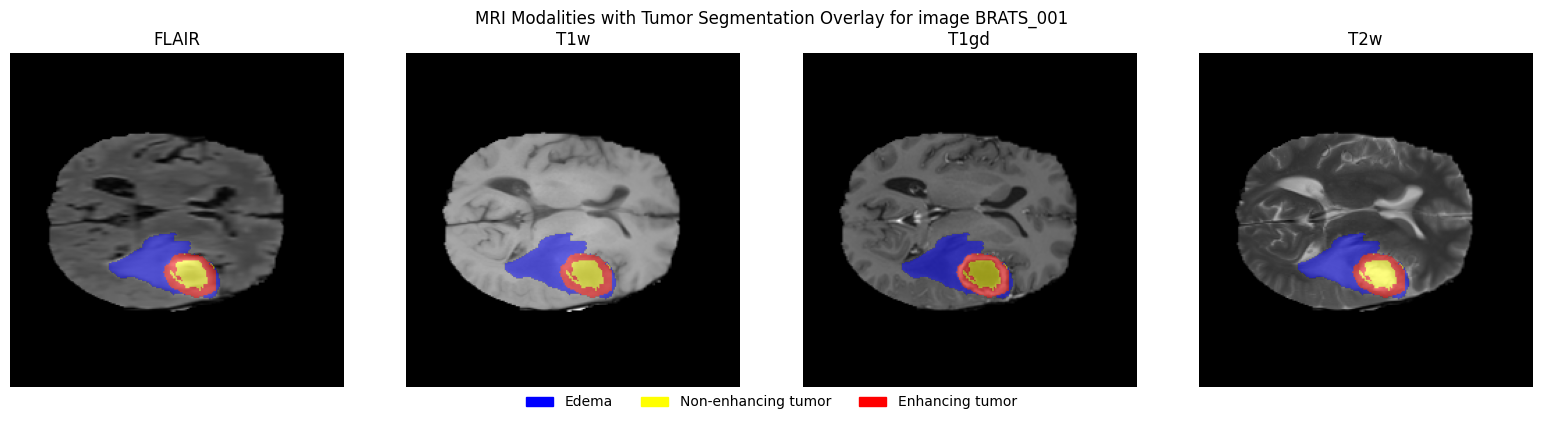

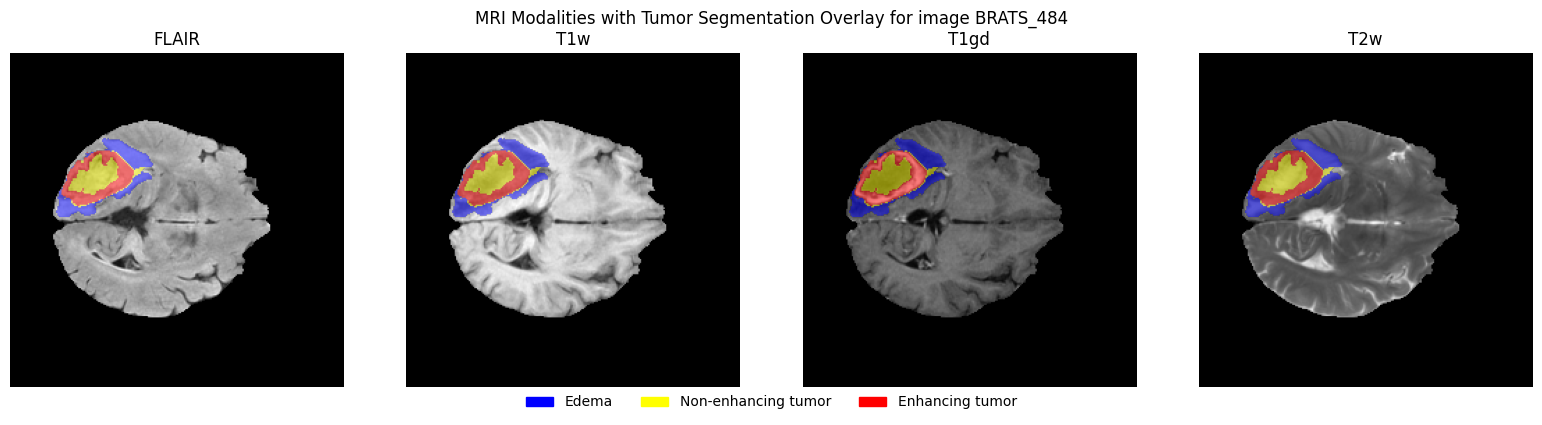

In [30]:
dataset = 'Task01_BrainTumour'
# Define modalities from dataset.json
modalities = ["FLAIR", "T1w", "T1gd", "T2w"]

# Define custom colormap for labels
colors = ["#00000000", "#0000FF", "#FFFF00", "#FF0000"]
cmap = ListedColormap(colors)

# Define legend
legend_patches = [
    matpatches.Patch(color='#0000FF', label='Edema'),
    matpatches.Patch(color='#FFFF00', label='Non-enhancing tumor'),
    matpatches.Patch(color='#FF0000', label='Enhancing tumor')
]

def get_img_path(mri):

    return f'{dataset}/imagesTr/{mri}.nii.gz'

def get_label_path(mri):
    return f'{dataset}/labelsTr/{mri}.nii.gz'

def visualize_mri(mri='', slice_index=None):
    # Access the relevant image and its label
    mri_data = nib.load(get_img_path(mri)).get_fdata()
    label_data = nib.load(get_label_path(mri)).get_fdata()
    # Default to the middle slice
    if slice_index is None:
        slice_index = mri_data.shape[2]//2
    label = label_data[:, :, slice_index]
    # Create subplots
    plot, subplots = plt.subplots(1, 4, figsize=(16,4))
    # Fill in the subplots
    for m in range(len(modalities)):
        # Extract slice for current modality
        mri_slice = mri_data[:, :, slice_index, m]
        # Create the plot using custom colormap 
        subplots[m].imshow(mri_slice, cmap='gray')
        subplots[m].imshow(label, cmap=cmap, alpha=0.5)
        subplots[m].set_title(modalities[m])
        subplots[m].axis('off')
    # Display
    plot.suptitle(f'MRI Modalities with Tumor Segmentation Overlay for image {mri}')
    # Format the legend
    plot.legend(handles=legend_patches, loc='lower center',
                bbox_to_anchor=(0.5,-0.05), ncol=3, frameon=False)
    plot.tight_layout()
    plot.show()

visualize_mri(mri='BRATS_001')
visualize_mri(mri='BRATS_484', slice_index=60)

## Brain tumor segmentation using U-Net

In [31]:
max_slices_per_volume = 20

# Create custom Dataset class
class BrainTumorDataset(Dataset):
    def __init__(self, image_ids, dataset_path):
        self.image_ids = image_ids
        self.dataset_path = dataset_path
        self.slices = []
        # Cache to avoid reloading the same volume from disk for every slice
        self.cache = {}

        for image_id in self.image_ids:
            # Only load header to get shape (cheap)
            image = nib.load(f"{dataset_path}/imagesTr/{image_id}.nii.gz")
            depth = image.shape[2]

            # Evenly sample slices across the volume depth
            slice_indices = np.linspace(0, depth - 1, max_slices_per_volume, dtype=int)
            for s in slice_indices:
                self.slices.append((image_id, s))

    def __len__(self):
        return len(self.slices)

    def load_volume(self, image_id):
        if image_id not in self.cache:
            image = nib.load(
                f"{self.dataset_path}/imagesTr/{image_id}.nii.gz"
            ).get_fdata().astype(np.float32)
            label = nib.load(
                f"{self.dataset_path}/labelsTr/{image_id}.nii.gz"
            ).get_fdata()
            self.cache[image_id] = (image, label)

            # Evict oldest entry to cap memory usage
            if len(self.cache) > 2:
                self.cache.pop(next(iter(self.cache)))

        return self.cache[image_id]

    def __getitem__(self, index):
        image_id, s = self.slices[index]

        # Load from cache where possible to avoid redundant disk reads
        image, label = self.load_volume(image_id)

        # Extract slice
        x = image[:, :, s, :]   # (H, W, 4)
        y = label[:, :, s]

        # Fix BraTS labels if needed
        y[y == 4] = 3

        # Normalize
        x = (x - np.mean(x)) / (np.std(x) + 1e-8)

        # Format for PyTorch
        x = np.transpose(x, (2, 0, 1))  # (4, H, W)

        x = torch.tensor(x, dtype=torch.float32)
        y = torch.tensor(y, dtype=torch.long)

        return x, y


class DoubleConvolution(nn.Module):
    def __init__(self, in_channel, out_channel):
        super().__init__()
        self.net = nn.Sequential(
            # Extract relevant features
            nn.Conv2d(in_channel, out_channel, 3, padding=1),
            nn.ReLU(inplace=True),
            # Refine extracted features
            nn.Conv2d(out_channel, out_channel, 3, padding=1),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.net(x)


class UNet(nn.Module):
    def __init__(self, in_channels=4, num_classes=4):
        super().__init__()

        self.down1 = DoubleConvolution(in_channels, 64)
        self.pool1 = nn.MaxPool2d(2)

        self.down2 = DoubleConvolution(64, 128)
        self.pool2 = nn.MaxPool2d(2)

        self.down3 = DoubleConvolution(128, 256)
        self.pool3 = nn.MaxPool2d(2)

        self.bottleneck = DoubleConvolution(256, 512)

        self.up3 = nn.ConvTranspose2d(512, 256, 2, stride=2)
        self.conv3 = DoubleConvolution(512, 256)

        self.up2 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.conv2 = DoubleConvolution(256, 128)

        self.up1 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.conv1 = DoubleConvolution(128, 64)

        self.final = nn.Conv2d(64, num_classes, 1)

    def forward(self, x):
        down1 = self.down1(x)
        down2 = self.down2(self.pool1(down1))
        down3 = self.down3(self.pool2(down2))

        bottleneck = self.bottleneck(self.pool3(down3))

        up3 = self.up3(bottleneck)
        # Skip connection: concatenate encoder features to recover spatial detail lost during pooling
        up3 = torch.cat([up3, down3], dim=1)
        up3 = self.conv3(up3)

        up2 = self.up2(up3)
        # Skip connection
        up2 = torch.cat([up2, down2], dim=1)
        up2 = self.conv2(up2)

        up1 = self.up1(up2)
        # Skip connection
        up1 = torch.cat([up1, down1], dim=1)
        up1 = self.conv1(up1)

        return self.final(up1)


def dice_loss(prediction, ground_truth, smooth=1e-5):
    # Transform raw scores into probabilities
    prediction = torch.softmax(prediction, dim=1)
    # Represent categories as binary lists
    target_encoding = F.one_hot(ground_truth, num_classes=4)
    # Align dimensions (Batch, H, W, C) -> (Batch, C, H, W)
    target_encoding = target_encoding.permute(0, 3, 1, 2).float()
    # Measure of correct predictions
    intersection = (prediction * target_encoding).sum(dim=(2, 3))
    # Measure of total predicted positive and true positive
    union = prediction.sum(dim=(2, 3)) + target_encoding.sum(dim=(2, 3))
    # Compute dice score with smoothing term for stability
    dice = (2.0 * intersection + smooth) / (union + smooth)
    return 1 - dice.mean()


# Hybrid loss to balance individual disadvantages
def combined_loss(prediction, target):
    cross_entropy = F.cross_entropy(prediction, target)
    dice_score = dice_loss(prediction, target)
    return cross_entropy + dice_score


def train(model, data_loader, optimizer, device):
    model.train()
    total_loss = 0
    for i, (x, y) in enumerate(data_loader):
        x, y = x.to(device), y.to(device)
        # Reset gradient calculations
        optimizer.zero_grad()
        # Pass input through U-Net
        prediction = model(x)
        # Evaluate the model's current effectiveness
        loss = combined_loss(prediction, y)
        # Backpropagate
        loss.backward()
        optimizer.step()
        # Track loss performance
        total_loss += loss.item()
        print(f"    Batch {i + 1}/{len(data_loader)}  loss: {loss.item():.4f}", end="\r")
    print()
    # Return averaged loss
    return total_loss / len(data_loader)


def compute_metrics(pred_mask, true_mask):
    # Compute Dice and Hausdorff scores for relevant regions
    regions = {
        "ET": [3],        # Enhancing tumor
        "TC": [2, 3],     # Tumor core: non-enhancing + enhancing
        "WT": [1, 2, 3],  # Whole tumor: edema + non-enhancing + enhancing
    }

    res = {}
    for name, labels in regions.items():
        # Binarize masks for the current region
        pred_bin = np.isin(pred_mask, labels)
        true_bin = np.isin(true_mask, labels)

        if true_bin.sum() == 0 and pred_bin.sum() == 0:
            # Both empty: perfect agreement by convention
            dice = 1.0
            hd95 = 0.0
        elif true_bin.sum() == 0 or pred_bin.sum() == 0:
            # One empty, one not: worst-case scores
            dice = 0.0
            hd95 = np.nan
        else:
            # Compute Dice coefficient
            intersection = (pred_bin & true_bin).sum()
            dice = (2 * intersection) / (pred_bin.sum() + true_bin.sum())
            # Compute 95th percentile Hausdorff distance
            hd95 = binary.hd95(pred_bin, true_bin)

        res[f"Dice_{name}"]      = dice
        res[f"Hausdorff_{name}"] = hd95

    return res


def evaluate(model, data_loader, device):
    model.eval()
    all_metrics = []

    with torch.no_grad():
        for i, (x, y) in enumerate(data_loader):
            print(f"    Evaluating batch {i + 1}/{len(data_loader)}", end="\r")
            # Get hard predictions via argmax over class scores
            prediction = model(x.to(device)).argmax(dim=1).cpu().numpy()
            for b in range(prediction.shape[0]):
                all_metrics.append(compute_metrics(prediction[b], y[b].numpy()))
    print()

    # Average each metric across all slices, ignoring nans
    avg = {}
    for key in all_metrics[0]:
        vals = [m[key] for m in all_metrics if not np.isnan(m[key])]
        avg[key] = np.mean(vals) if vals else np.nan
    return avg

In [ ]:
dataset = 'Task01_BrainTumour'
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

image_ids = sorted([f.replace(".nii.gz", "")
                    for f in os.listdir("Task01_BrainTumour/imagesTr")])

mri_ids = sorted([
    # Remove ".nii.gz"
    f[:-7] 
    for f in os.listdir(f'{dataset}/imagesTr')
    if f.endswith(".nii.gz")
])

num_splits = 5
kf = KFold(n_splits=num_splits, shuffle=True, random_state=42)
fold_results = []

for fold, (train_index, val_index) in enumerate(kf.split(mri_ids)):
    timestamp = datetime.datetime.now().strftime("%I:%M:%S %p")
    print(f"\n── Fold {fold + 1}/{num_splits} [{timestamp}] ──")

    train_ids = [mri_ids[i] for i in train_index]
    val_ids   = [mri_ids[i] for i in val_index]

    training_dataset   = BrainTumorDataset(train_ids, dataset)
    validation_dataset = BrainTumorDataset(val_ids,   dataset)

    training_loader   = torch.utils.data.DataLoader(training_dataset, batch_size=4, shuffle=True)
    validation_loader = torch.utils.data.DataLoader(validation_dataset, batch_size=4)

    model = UNet().to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

    num_epochs = 5
    for epoch in range(num_epochs):
        loss = train(model, training_loader, optimizer, device)
        timestamp = datetime.datetime.now().strftime("%I:%M:%S %p")
        print(f"Fold {fold+1}, Epoch {epoch+1}, Loss: {loss:.4f} [{timestamp}]")

    # Evaluate on held-out fold and record results
    print(f"  Evaluating fold {fold + 1}...")
    metrics = evaluate(model, validation_loader, device)
    metrics["Fold"] = fold + 1
    fold_results.append(metrics)

    for k, v in metrics.items():
        if k != "Fold":
            print(f"  {k}: {v:.4f}" if not np.isnan(v) else f"  {k}: NaN")

# Format and print summary table
print("\n" + "=" * 32)
print(f"{num_splits}-FOLD CROSS-VALIDATION RESULTS")
print("=" * 32)
header = f"{'Fold':>6}  {'Dice_ET':>8}  {'Dice_TC':>8}  {'Dice_WT':>8}  {'Hausdorff_ET':>13}  {'Hausdorff_TC':>13}  {'Hausdorff_WT':>13}"
print(header)
print("-" * len(header))

for r in fold_results:
    print(f"{r['Fold']:>6}  {r['Dice_ET']:>8.4f}  {r['Dice_TC']:>8.4f}  {r['Dice_WT']:>8.4f}  "
          f"{r['Hausdorff_ET']:>13.4f}  {r['Hausdorff_TC']:>13.4f}  {r['Hausdorff_WT']:>13.4f}")

# Compute and print averages, skip nans
print("-" * len(header))
avg_row = {}
for key in ["Dice_ET", "Dice_TC", "Dice_WT", "Hausdorff_ET", "Hausdorff_TC", "Hausdorff_WT"]:
    vals = [r[key] for r in fold_results if not np.isnan(r[key])]
    avg_row[key] = np.mean(vals) if vals else np.nan

print(f"{'Avg':>6}  {avg_row['Dice_ET']:>8.4f}  {avg_row['Dice_TC']:>8.4f}  {avg_row['Dice_WT']:>8.4f}  "
      f"{avg_row['Hausdorff_ET']:>13.4f}  {avg_row['Hausdorff_TC']:>13.4f}  {avg_row['Hausdorff_WT']:>13.4f}")


── Fold 1/5 [01:00:00 AM]──


KeyboardInterrupt: 